# Cardialyse ECG Processing Pipeline
Full workflow: ECG Image → Signal → R-Peaks → HRV Features

In [1]:
# Install required packages (run once)
!pip install numpy pandas matplotlib opencv-python scikit-image scipy neurokit2

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu
from scipy.signal import butter, filtfilt, find_peaks, welch
import pandas as pd
import neurokit2 as nk

## ⿡ Load and Display ECG Image

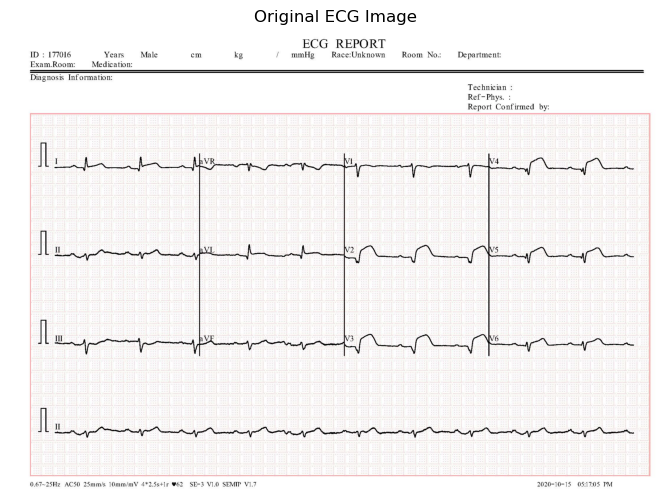

In [3]:
# Path to your ECG image
img_path = 'MI(100)[1].jpg'  # adjust path

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))
plt.imshow(img_rgb)
plt.title('Original ECG Image')
plt.axis('off')
plt.show()

## ⿢ Preprocess Image (Grayscale + Denoise + Contrast Enhancement)

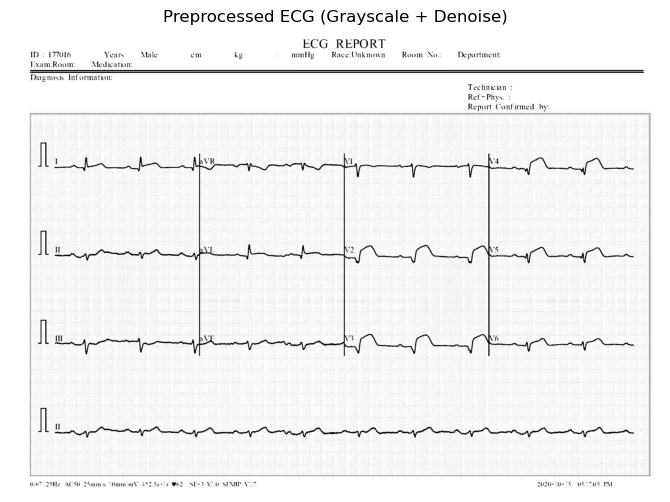

In [4]:
def preprocess_ecg(img, clahe=True):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if clahe:
        clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray = clahe_obj.apply(gray)
    gray = cv2.medianBlur(gray, 3)
    return gray

gray_img = preprocess_ecg(img)
plt.figure(figsize=(12,6))
plt.imshow(gray_img, cmap='gray')
plt.title('Preprocessed ECG (Grayscale + Denoise)')
plt.axis('off')
plt.show()

## ⿣ Extract Waveform from Image

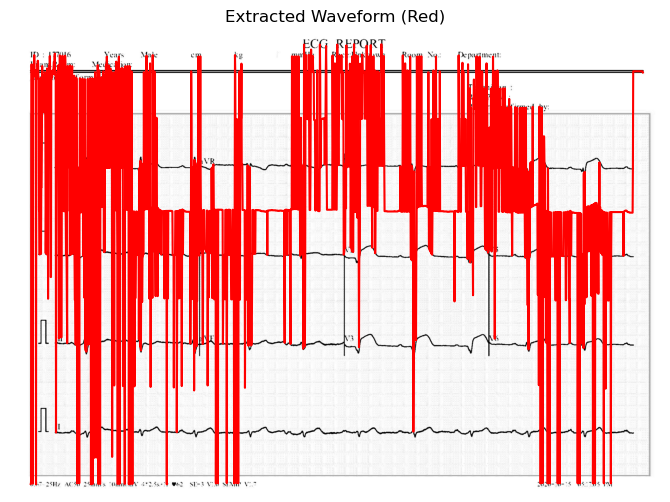

In [5]:
def extract_waveform(gray_img):
    thresh = threshold_otsu(gray_img)
    bw = gray_img < thresh  # waveform is darker
    skeleton = skeletonize(bw)
    xs, ys = [], []
    h, w = skeleton.shape
    for x in range(w):
        rows = np.where(skeleton[:, x])[0]
        if len(rows) == 0:
            continue
        y_med = int(np.median(rows))
        xs.append(x)
        ys.append(y_med)
    return np.array(xs), np.array(ys), skeleton

xs, ys, skeleton = extract_waveform(gray_img)

# Plot skeleton overlay
plt.figure(figsize=(12,6))
plt.imshow(gray_img, cmap='gray')
plt.plot(xs, ys, color='red')
plt.title('Extracted Waveform (Red)')
plt.axis('off')
plt.show()

## ⿤ Convert Pixels → Time & Amplitude

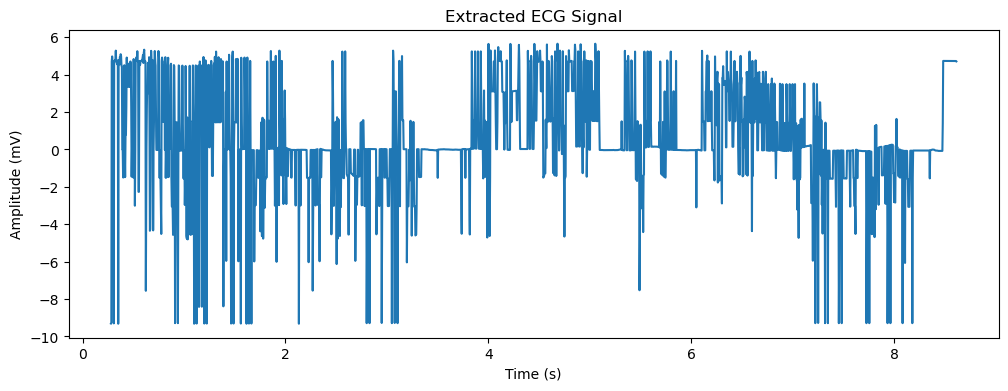

In [6]:
# Parameters
pixels_per_mm = 10  # adjust manually if needed
paper_speed = 25.0  # mm/s
desired_fs = 500    # Hz

def pixels_to_signal(xs, ys, pixels_per_mm, paper_speed=25.0, desired_fs=500):
    fs_est = pixels_per_mm * paper_speed
    dt = 1.0 / fs_est
    t_pixels = xs * dt
    baseline = np.median(ys)
    mV_per_pixel = 1.0 / (10.0 * pixels_per_mm)
    amps_mV = (baseline - ys) * mV_per_pixel
    t_uniform = np.arange(t_pixels.min(), t_pixels.max(), 1.0/desired_fs)
    amps_uniform = np.interp(t_uniform, t_pixels, amps_mV)
    return t_uniform, amps_uniform, fs_est

t, ecg_signal, fs = pixels_to_signal(xs, ys, pixels_per_mm, paper_speed, desired_fs)

plt.figure(figsize=(12,4))
plt.plot(t, ecg_signal)
plt.title('Extracted ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.show()

## ⿥ Filter ECG Signal (Bandpass 0.5–40 Hz)

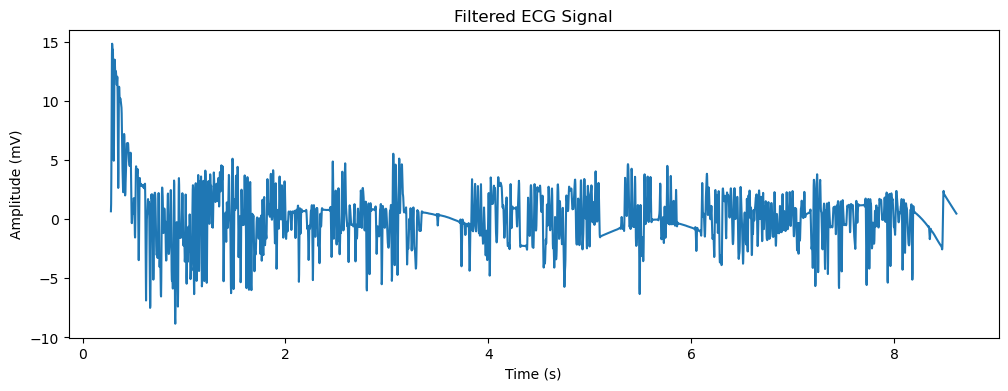

In [7]:
def butter_bandpass(lowcut, highcut, fs, order=3):
    from scipy.signal import butter
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

def filter_ecg(signal, fs, lowcut=0.5, highcut=40.0):
    b, a = butter_bandpass(lowcut, highcut, fs)
    from scipy.signal import filtfilt
    filtered = filtfilt(b, a, signal)
    return filtered

ecg_filtered = filter_ecg(ecg_signal, fs)
plt.figure(figsize=(12,4))
plt.plot(t, ecg_filtered)
plt.title('Filtered ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.show()

## ⿦ R-Peak Detection using NeuroKit2

Number of R-peaks detected: 21


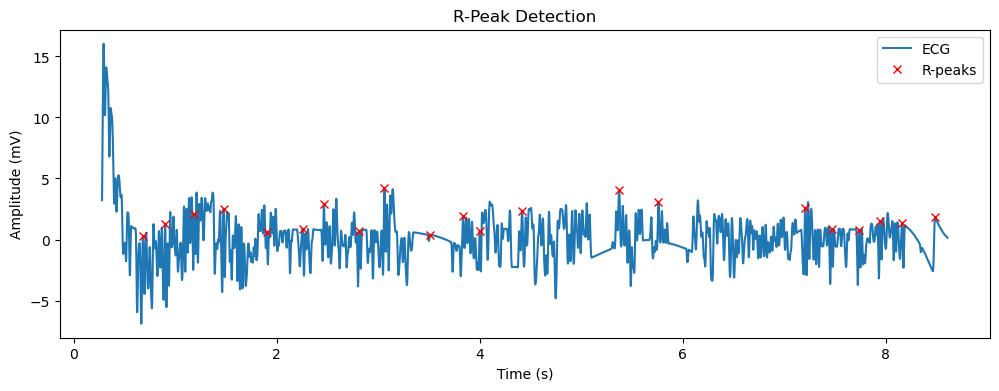

In [8]:
# Clean ECG with NeuroKit2 (optional but recommended)
ecg_cleaned = nk.ecg_clean(ecg_filtered, sampling_rate=fs)

# Detect R-peaks
signals, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs)
r_peaks = info['ECG_R_Peaks']

print('Number of R-peaks detected:', len(r_peaks))

# Visualize R-peaks
plt.figure(figsize=(12,4))
plt.plot(t, ecg_cleaned, label='ECG')
plt.plot(t[r_peaks], ecg_cleaned[r_peaks], 'rx', label='R-peaks')
plt.title('R-Peak Detection')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()

## ⿧ Compute RR Intervals & Heart Rate

In [9]:
rr_intervals = np.diff(t[r_peaks])
heart_rate = 60 / rr_intervals
print('Mean HR (bpm):', np.mean(heart_rate))
print('RR intervals (s):', rr_intervals)

Mean HR (bpm): 199.75458146625752
RR intervals (s): [0.218 0.288 0.288 0.424 0.354 0.21  0.35  0.246 0.452 0.324 0.164 0.416
 0.956 0.388 1.446 0.26  0.272 0.208 0.214 0.326]


## ⿨ Extract HRV Features

C:\Users\shiva\anaconda3\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
C:\Users\shiva\anaconda3\Lib\site-packages\neurokit2\complexity\entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)


   HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0       780.4  598.603146         NaN         NaN         NaN         NaN   

   HRV_SDANN5  HRV_SDNNI5   HRV_RMSSD    HRV_SDSD  ...  HRV_SampEn  \
0         NaN         NaN  844.097276  867.148854  ...    1.386294   

   HRV_ShanEn  HRV_FuzzyEn  HRV_MSEn  HRV_CMSEn  HRV_RCMSEn    HRV_CD  \
0    4.221928     0.886741       NaN        NaN         NaN  1.793021   

    HRV_HFD   HRV_KFD   HRV_LZC  
0  1.975416  1.900586  1.296578  

[1 rows x 82 columns]


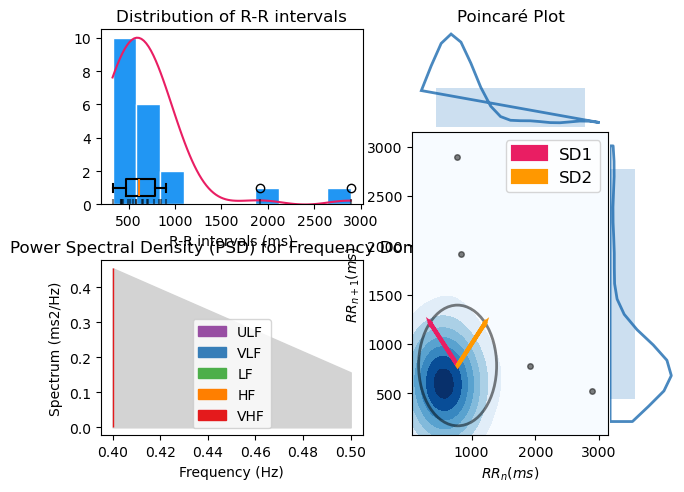

In [10]:
hrv_features = nk.hrv(info, sampling_rate=fs, show=True)
print(hrv_features)

## ⿩ Save Features to CSV

In [12]:
hrv_features.to_csv('ecg_features.csv', index=False)
print('Features saved to ecg_features.csv')

Features saved to ecg_features.csv
